In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout

#loading the MNIST dataset
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

In [11]:
#analyzing the image
print(x_train)

#for checking the size
print(x_train.shape)

print(y_train)

#for checking the size of the y_train
print(y_train.shape)

print(x_test)
#for checking the size of the x_test
print(x_test.shape)

print(y_test)
#for checking the size of
print(y_test.shape)

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]
(60000, 28, 28)
[5 0 4 ... 5 6 8]
(60000,)
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 

In [12]:
#preprocesing the data
x_train =x_train.reshape(-1,784).astype("float32")/255.0
x_test = x_test.reshape(-1,784).astype("float32")/255.0

In [13]:
#ONE HOT ENCODING
y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

In [14]:
#developing the model
ann = tf.keras.models.Sequential()

for _ in range(9):
    ann.add(tf.keras.layers.Dense(units=6, use_bias=False))
    #Batch normalization is added because it will normalize the output of each layer means higher outputs get normalized and If it is not normalized then each layer output is random and difficult to train the next layer
    ann.add(tf.keras.layers.BatchNormalization())
    ann.add(tf.keras.layers.Activation('relu'))
    #drop out means it will randomly drops some neurons so that it will start learning instead of memorizing as here we are passing 0.1 then it means 10% of neurons are getting skipped
    ann.add(tf.keras.layers.Dropout(0.1))

#adding output layer
#here if our model has the output based in 10 columns that why we need to add the 10 neurons inside the output layer
#means if we have to choose the only one output then use softmax and if we had to choose the multiple outputs then use sigmoid
ann.add(tf.keras.layers.Dense(units=10 , activation='softmax'))


In [15]:
#using the optimizer to run the code
ann.compile(optimizer='adam', loss='mean_squared_error',metrics=['accuracy'])

#to train the model
history = ann.fit(x_train, y_train, batch_size = 32, epochs = 20 , validation_data=(x_test, y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.1585 - loss: 0.0882 - val_accuracy: 0.2748 - val_loss: 0.0835
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2736 - loss: 0.0807 - val_accuracy: 0.4156 - val_loss: 0.0719
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3145 - loss: 0.0774 - val_accuracy: 0.4910 - val_loss: 0.0689
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3384 - loss: 0.0759 - val_accuracy: 0.4558 - val_loss: 0.0659
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3469 - loss: 0.0748 - val_accuracy: 0.4446 - val_loss: 0.0656
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3556 - loss: 0.0738 - val_accuracy: 0.4691 - val_loss: 0.0627
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.3537 - loss: 0.0737 - val_accuracy: 0.4556 - val_loss: 0.0635
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3560 - loss: 0.0734

In [16]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Final Training Accuracy: 0.3744
Final Validation Accuracy: 0.4563


In [17]:
test_loss, test_accuracy = ann.evaluate(x_test, y_test, verbose=0)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.4562999904155731


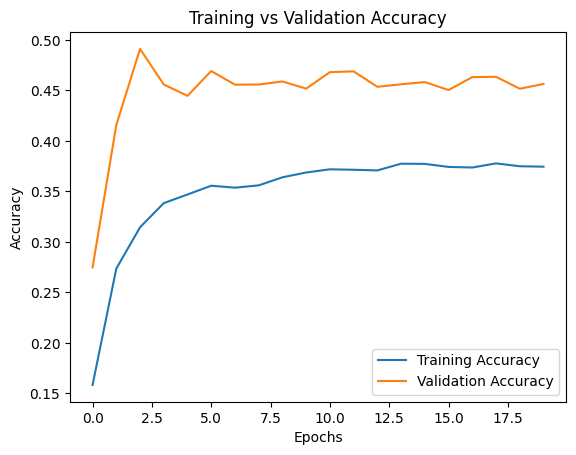

In [18]:
#plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()